In [1]:
import pandas as pd
df = pd.read_csv("retail_cleaned.csv")


In [7]:
df.head()
df.shape
# df.describe()
df.columns
# df.dtypes
# df.isnull().sum()
# df.duplicated().sum()

Index(['Order ID', 'Order Date', 'Ship Date', 'Customer ID', 'Customer Name',
       'City', 'State', 'Region', 'Product Name', 'Category', 'Quantity',
       'Discount', 'Sales', 'Profit', 'Payment Mode', 'Sales Channel',
       'Customer Segment'],
      dtype='str')

In [44]:
df["Sales"].sum()
df[["Sales", "Profit"]].mean().round(2)
df["Sales"].agg(["min", "max"])
df["Profit"].agg(["max","min"])



max    25350
min     -250
Name: Profit, dtype: int64

In [56]:
df.groupby("Category")[["Sales","Profit"]].sum()
df.groupby("Category")["Sales"].sum().sort_values(ascending=False)
df.groupby("Category")["Profit"].sum().sort_values(ascending=False)
df.groupby("Category")["Profit"].sum().sort_values(ascending=True)

Category
Stationery      10645
Accessories     48975
Furniture      307856
Electronics    578988
Name: Profit, dtype: int64

In [63]:
df.groupby("Region")[["Sales","Profit"]].sum()
df.groupby("Region")["Sales"].sum().sort_values(ascending=False)
df.groupby("Region")["Profit"].sum().sort_values(ascending=False)
df.groupby("Region")["Profit"].sum().sort_values

<bound method Series.sort_values of Region
East      61161
North    176132
South    572092
West     137079
Name: Profit, dtype: int64>

In [19]:
df["Customer ID"].nunique()
df.groupby("Customer ID")["Sales"].sum().sort_values(ascending=False).head(10)
df.groupby("Customer ID")["Profit"].sum().sort_values(ascending=False).head(10)
df.groupby("Customer ID")["Profit"].sum().sort_values(ascending=True).head(1)

Customer ID
C-1040    77
Name: Profit, dtype: int64

In [23]:
df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)
df.groupby("Product Name")["Profit"].sum().sort_values(ascending=False).head(10)
df.groupby("Product Name")["Profit"].sum().sort_values(ascending=True).head(10)
df["Product Name"].nunique()


18

In [ ]:
df.groupby("Sales Channel")[["Sales","Profit"]].sum()
df.groupby("Sales Channel")["Order ID"].nunique()
df.groupby("Sales Channel")["Sales"].sum().sort_values(ascending=False).head(1)


Sales Channel
Marketplace     164
Online          139
Retail Store    166
Name: Order ID, dtype: int64

In [ ]:
df.groupby("Payment Mode")[["Sales","Profit"]].sum()
df.groupby("Payment Mode")["Order ID"].nunique()
df.groupby("Payment Mode")["Sales"].sum().sort_values(ascending=False).head(1)

Payment Mode
Debit Card    1841245
Name: Sales, dtype: int64

In [34]:
df.groupby("Category")["Quantity"].sum()
df.groupby("Category")["Quantity"].mean()
df.groupby("Category")["Discount"].mean().sort_values(ascending=False).head(1)
df.groupby("Category")["Discount"].mean().sort_values(ascending=True).head(1)


Category
Furniture    0.108101
Name: Discount, dtype: float64

In [ ]:
df.groupby(df["Order Date"].dt.year)["Sales"].sum()
df.groupby(df["Order Date"].dt.year)["Profit"].sum()
df.groupby(df["Order Date"].dt.year)["Sales"].sum().sort_values(ascending=False).head(1)
df.groupby(df["Order Date"].dt.year)["Profit"].sum().sort_values(ascending=False).head(1)

0      2025
1      2025
2      2025
3      2025
4      2025
       ... 
464    2025
465    2025
466    2025
467    2025
468    2025
Name: Order Date, Length: 469, dtype: int32

In [ ]:
# Profit Margin by Category
category = df.groupby("Category")[["Sales", "Profit"]].sum()
category["Profit Margin %"] = (category["Profit"] / category["Sales"] * 100).round(2)
category

# Monthly Sales
df["Month"] = df["Order Date"].dt.month
df.groupby("Month")["Sales"].sum().sort_index()

# . Monthly Profit
df.groupby("Month")["Profit"].sum().sort_index()

# Discount vs Profit
df[["Discount", "Profit"]].corr()

# High Sales but Low Profit Products
product = df.groupby("Product Name")[["Sales", "Profit"]].sum()

# Loss-Making Products
product_profit = df.groupby("Product Name")["Profit"].sum()
product_profit[product_profit < 0].sort_values()

# Customer Sales vs Profit
customer = df.groupby("Customer ID")[["Sales", "Profit"]].sum()
customer.sort_values("Sales", ascending=False).head(10)

# Category + Region Analysis
df.groupby(["Region", "Category"])[["Sales", "Profit"]].sum()

Sales  Profit
Region Category                    
East   Accessories    24460    3442
       Electronics   272753   29668
       Furniture     166370   26458
       Stationery      9795    1593
North  Accessories    46997    8565
       Electronics   816985   92031
       Furniture     579515   72331
       Stationery     22746    3205
South  Accessories   224011   30298
       Electronics  2803405  357132
       Furniture    1428540  180058
       Stationery     36366    4604
West   Accessories    70301    6670
       Electronics   777715  100157
       Furniture     195830   29009
       Stationery     14054    1243

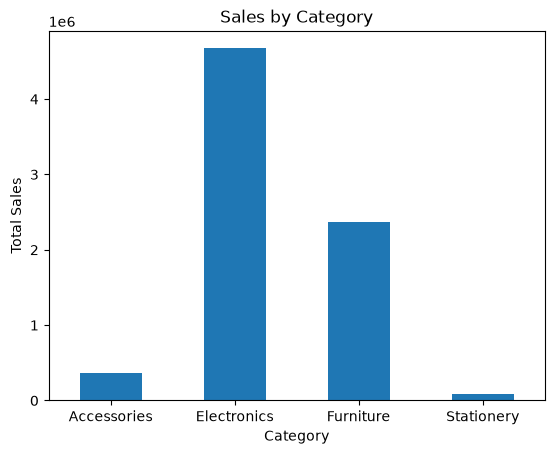

In [ ]:
# Sales by Category
import matplotlib.pyplot as plt
sales_category = df.groupby("Category")["Sales"].sum()
sales_category.plot(kind="bar")
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.show()

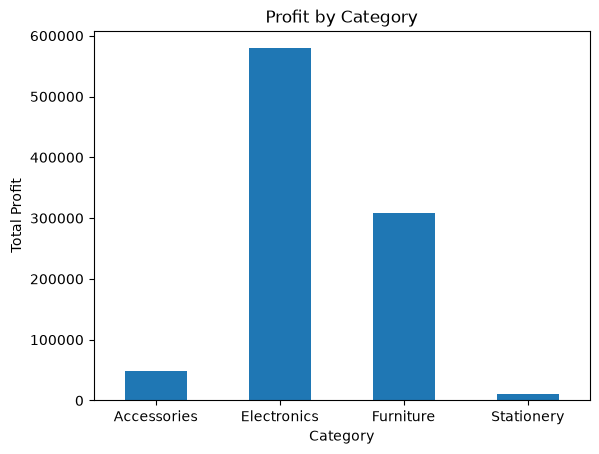

In [56]:
# Profit by Category

profit_category = df.groupby("Category")["Profit"].sum()
profit_category.plot(kind="bar")
plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Total Profit")
plt.xticks(rotation=0)
plt.show()

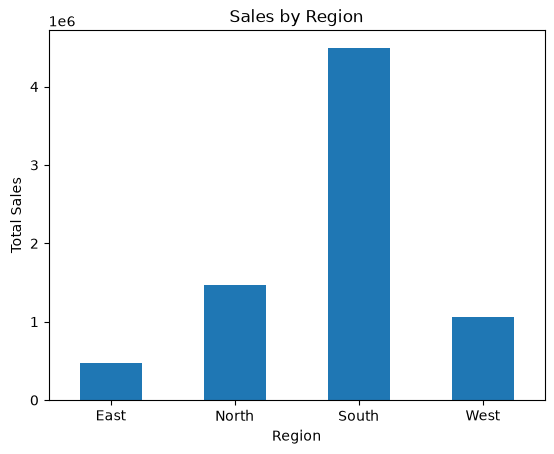

In [57]:
# Sales by Region
sales_region = df.groupby("Region")["Sales"].sum()
sales_region.plot(kind="bar")
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.show()

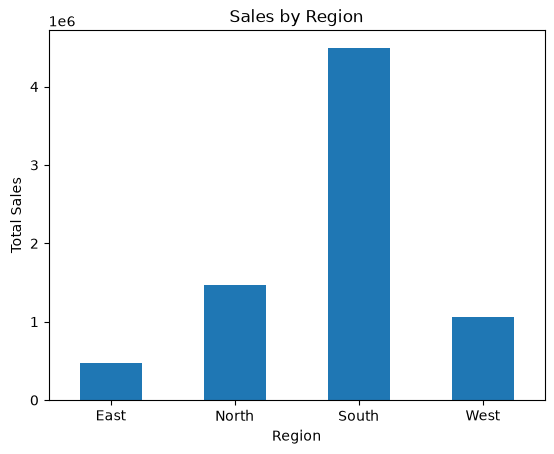

In [58]:
# Sales by Region
sales_region = df.groupby("Region")["Sales"].sum()
sales_region.plot(kind="bar")
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.show()

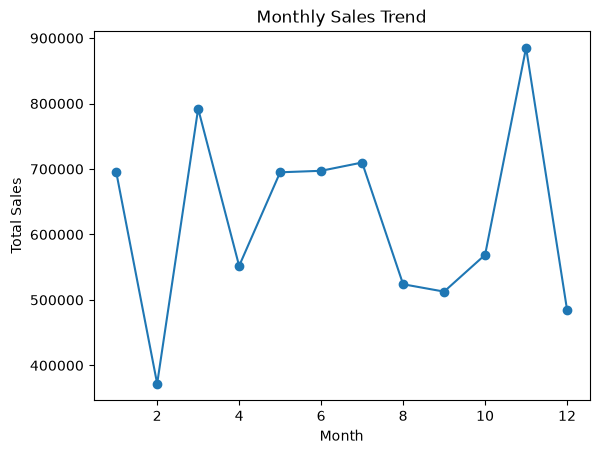

In [60]:
# Monthly Sales Trend
monthly_sales = df.groupby(df["Order Date"].dt.month)["Sales"].sum()
monthly_sales.plot(kind="line", marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()